In [118]:
import numpy as np
import pandas as pd
import os
import pickle
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
import tensorflow.keras as keras
import matplotlib.pyplot as plt
import cv2

In [71]:
data_dir = r'../data/processed/train_val_test'

X_train_image = np.load(os.path.join(data_dir, 'X_train.npy'))
y_train_image = np.load(os.path.join(data_dir, 'y_train.npy'))

X_val_image = np.load(os.path.join(data_dir, 'X_val.npy'))
y_val_image = np.load(os.path.join(data_dir, 'y_val.npy'))

X_test_image = np.load(os.path.join(data_dir, 'X_test.npy'))
y_test_image = np.load(os.path.join(data_dir, 'y_test.npy'))

In [72]:
with open(os.path.join(data_dir, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)

In [73]:
print(f"✅ X_train_image shape: {X_train_image.shape}")
print(f"✅ y_train_image shape: {y_train_image.shape}")
print(f"✅ X_val_image shape: {X_val_image.shape}")
print(f"✅ y_val_image shape: {y_val_image.shape}")
print(f"✅ X_test_image shape: {X_test_image.shape}")
print(f"✅ y_test_image shape: {y_test_image.shape}")
print(f"\n✅ Classes: {le.classes_}")
print(f"✅ Num classes: {NUM_CLASSES}")

✅ X_train_image shape: (5106, 224, 224, 1)
✅ y_train_image shape: (5106, 8)
✅ X_val_image shape: (1094, 224, 224, 1)
✅ y_val_image shape: (1094, 8)
✅ X_test_image shape: (1095, 224, 224, 1)
✅ y_test_image shape: (1095, 8)

✅ Classes: ['Atelectasis' 'Cardiomegaly' 'Fibrosis/Scarring' 'Normal' 'Other'
 'Pleural Effusion' 'Pneumonia/Infiltrate' 'Pneumothorax']
✅ Num classes: 8


In [74]:
def build_efficientnet_model(num_classes=8, feature_dim=256):
    inputs = layers.Input(shape=(224, 224, 1), name='image_input')
    
    x = layers.Concatenate(name='channel_expand')([inputs, inputs, inputs])
    
    base_model = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False
    
    x = base_model(x, training=False)          # ← ده اللي كان ناقص
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    image_features = layers.Dense(
        feature_dim, activation='relu', name='image_features'
    )(x)
    
    model = keras.Model(inputs, image_features, name='image_model')
    return model, base_model

In [75]:
image_model, base_model = build_efficientnet_model(num_classes=NUM_CLASSES, feature_dim=256)
print(image_model.summary())

Model: "image_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_expand      │ (None, 224, 224,  │          0 │ image_input[0][0… │
│ (Concatenate)       │ 3)                │            │ image_input[0][0… │
│                     │                   │            │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 7, 7,      │ 10,783,535 │ channel_expand[0… │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 512)       │    786,944 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 512)       │          0 │ dense_20[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 256)       │    131,328 │ dropout_20[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,701,807 (44.64 MB)

 Trainable params: 918,272 (3.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

None


In [76]:
df = pd.read_csv(r'../data/processed/FinalData.csv')
print(f"✅ Clinical data loaded: {len(df)} rows")
print(f"✅ Columns: {df.columns.tolist()}")

✅ Clinical data loaded: 7295 rows
✅ Columns: ['uid', 'filename', 'projection', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'impression_class']


In [77]:
df.head()

,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression,impression_class
0,1,1_IM-0001-4001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,Positive TB test,NaN,The cardiac silhouette and mediastinum size ar...,Normal chest x-,Normal
1,1,1_IM-0001-3001.dcm.png,Lateral,normal,normal,Xray Chest PA and Lateral,Positive TB test,NaN,The cardiac silhouette and mediastinum size ar...,Normal chest x-,Normal
2,2,2_IM-0652-1001.dcm.png,Frontal,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,NaN,Borderline cardiomegaly. Midline sternotomy . ...,No acute pulmonary findings.,Normal
3,2,2_IM-0652-2001.dcm.png,Lateral,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,NaN,Borderline cardiomegaly. Midline sternotomy . ...,No acute pulmonary findings.,Normal
4,3,3_IM-1384-1001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",Unknown,"No displaced rib fractures, pneumothorax, or p...","No displaced rib fractures, pneumothorax, or p...",Normal


In [78]:
from sklearn.model_selection import train_test_split
train_indices, temp_indices = train_test_split(
    range(len(df)), test_size=0.30, random_state=42, 
    stratify=df['impression_class']
)

val_indices, test_indices = train_test_split(
    temp_indices, test_size=0.50, random_state=42,
    stratify=df.iloc[temp_indices]['impression_class']
)

In [79]:
train_text = df.iloc[train_indices][['impression', 'MeSH',"Problems","indication","findings"]].values
val_text = df.iloc[val_indices][['impression', 'MeSH',"Problems","indication","findings"]].values
test_text = df.iloc[test_indices][['impression', 'MeSH',"Problems","indication","findings"]].values

In [80]:
print(train_text)

[['No acute cardiopulmonary abnormality.'
  'Osteophyte/thoracic vertebrae/multiple;Nodule/heart/left/small;Calcified Granuloma/heart/left/small'
  'Osteophyte;Nodule;Calcified Granuloma'
  'XXXX and congestion for months.'
  'There are T-spine osteophytes. Small nodule projecting near the left heart  is unchanged from  and appears calcified. This  represents a calcified granuloma. The cardiomediastinal silhouette and pulmonary vasculature are within normal limits. There is no pneumothorax or pleural effusion. There are no focal areas of consolidation.']
 ['No evidence of active disease.' 'normal' 'normal'
  'Nausea, vomiting, preop for surgery'
  'The heart size and pulmonary vascularity appear within normal limits. The lungs are free of focal airspace disease. No pleural effusion or pneumothorax is seen.']
 ['1. Suspected mild patchy right upper lobe pneumonia, for which clinical correlation is recommended.'
  'Opacity/lung/upper lobe/right/posterior/patchy/mild;Lung Diseases, Inters

In [81]:
print(f"\n✅ Train text: {len(train_text)}")
print(f"✅ Val text: {len(val_text)}")
print(f"✅ Test text: {len(test_text)}")
print(f"\n📌 Sample text: {train_text[0][:100]}...")


✅ Train text: 5106
✅ Val text: 1094
✅ Test text: 1095

📌 Sample text: ['No acute cardiopulmonary abnormality.'
 'Osteophyte/thoracic vertebrae/multiple;Nodule/heart/left/small;Calcified Granuloma/heart/left/small'
 'Osteophyte;Nodule;Calcified Granuloma' 'XXXX and congestion for months.'
 'There are T-spine osteophytes. Small nodule projecting near the left heart  is unchanged from  and appears calcified. This  represents a calcified granuloma. The cardiomediastinal silhouette and pulmonary vasculature are within normal limits. There is no pneumothorax or pleural effusion. There are no focal areas of consolidation.']...


In [82]:
train_text = [str(text) if not (isinstance(text, float) and np.isnan(text)) else '' 
              for text in train_text]
val_text = [str(text) if not (isinstance(text, float) and np.isnan(text)) else '' 
            for text in val_text]
test_text = [str(text) if not (isinstance(text, float) and np.isnan(text)) else '' 
             for text in test_text]

In [ ]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
MAX_WORDS = 5000 
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 128 

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<UNK>')
tokenizer.fit_on_texts(train_text)

In [84]:
train_sequences = tokenizer.texts_to_sequences(train_text)
val_sequences = tokenizer.texts_to_sequences(val_text)
test_sequences = tokenizer.texts_to_sequences(test_text)

In [85]:
X_train_text = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_val_text = pad_sequences(val_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_text = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')


In [86]:
print(f"✅ Train text sequences: {X_train_text.shape}")
print(f"✅ Val text sequences: {X_val_text.shape}")
print(f"✅ Test text sequences: {X_test_text.shape}")
print(f"✅ Vocabulary size: {len(tokenizer.word_index)}")


✅ Train text sequences: (5106, 100)
✅ Val text sequences: (1094, 100)
✅ Test text sequences: (1095, 100)
✅ Vocabulary size: 3555


In [87]:
with open(os.path.join(data_dir, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)
print(f"✅ Tokenizer saved!")

✅ Tokenizer saved!


In [ ]:
SEQ_LENS = {
    'impression': 100,
    'findings':   150,
    'mesh':        50,
    'indication':  80,
    'problems':    50
}

def build_text_branch(vocab_size, seq_len, embedding_dim, lstm_units, name):
    inp = keras.Input(shape=(seq_len,), name=f'{name}_input')
    x = layers.Embedding(vocab_size, embedding_dim, mask_zero=True)(inp)
    x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=False))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(lstm_units, activation='relu')(x)
    return inp, x

def build_clinical_bilstm(vocab_size=MAX_WORDS, embedding_dim=EMBEDDING_DIM):
    imp_inp,  imp_feat  = build_text_branch(vocab_size, SEQ_LENS['impression'], embedding_dim, 64, 'impression')
    find_inp, find_feat = build_text_branch(vocab_size, SEQ_LENS['findings'],   embedding_dim, 64, 'findings')
    mesh_inp, mesh_feat = build_text_branch(vocab_size, SEQ_LENS['mesh'],       embedding_dim, 32, 'mesh')
    ind_inp,  ind_feat  = build_text_branch(vocab_size, SEQ_LENS['indication'], embedding_dim, 32, 'indication')
    prob_inp, prob_feat = build_text_branch(vocab_size, SEQ_LENS['problems'],   embedding_dim, 32, 'problems')

    fused = layers.Concatenate(name='clinical_concat')(
        [imp_feat, find_feat, mesh_feat, ind_feat, prob_feat]
    )  # [batch, 64+64+32+32+32] = [batch, 224]

    x = layers.Dense(256, activation='relu')(fused)
    x = layers.Dropout(0.4)(x)
    clinical_features = layers.Dense(128, activation='relu', name='clinical_features')(x)

    model = keras.Model(
        inputs=[imp_inp, find_inp, mesh_inp, ind_inp, prob_inp],
        outputs=clinical_features,
        name='clinical_bilstm_model'
    )
    return model

In [89]:
def build_fusion_model(num_classes=8, vocab_size=MAX_WORDS):
    # Image input
    image_input = keras.Input(shape=(224, 224, 1), name='image_input')

    # Text inputs
    imp_input  = keras.Input(shape=(SEQ_LENS['impression'],), name='impression_input')
    find_input = keras.Input(shape=(SEQ_LENS['findings'],),   name='findings_input')
    mesh_input = keras.Input(shape=(SEQ_LENS['mesh'],),       name='mesh_input')
    ind_input  = keras.Input(shape=(SEQ_LENS['indication'],), name='indication_input')
    prob_input = keras.Input(shape=(SEQ_LENS['problems'],),   name='problems_input')

    # Image features
    img_model, _ = build_efficientnet_model(feature_dim=256, num_classes=num_classes)
    img_features = img_model(image_input)  # [batch, 256]

    # Clinical features
    clin_model = build_clinical_bilstm(vocab_size=vocab_size)
    clin_features = clin_model([imp_input, find_input, mesh_input, ind_input, prob_input])  # [batch, 128]

    # Fusion
    fused = layers.Concatenate(name='fusion')([img_features, clin_features])  # [batch, 384]

    x = layers.Dense(256, activation='relu')(fused)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(
        inputs=[image_input, imp_input, find_input, mesh_input, ind_input, prob_input],
        outputs=outputs,
        name='fusion_model'
    )
    return model

In [ ]:
all_texts = (
    df['impression'].fillna('').tolist() +
    df['findings'].fillna('').tolist() +
    df['MeSH'].fillna('').tolist() +
    df['indication'].fillna('').tolist() +
    df['Problems'].fillna('').tolist()
)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<UNK>')
tokenizer.fit_on_texts(all_texts)

def encode_column(df_col, maxlen):
    seqs = tokenizer.texts_to_sequences(df_col.fillna('').tolist())
    return pad_sequences(seqs, maxlen=maxlen, padding='post')

X_train_imp  = encode_column(df.iloc[train_indices]['impression'], SEQ_LENS['impression'])
X_train_find = encode_column(df.iloc[train_indices]['findings'],   SEQ_LENS['findings'])
X_train_mesh = encode_column(df.iloc[train_indices]['MeSH'],       SEQ_LENS['mesh'])
X_train_ind  = encode_column(df.iloc[train_indices]['indication'], SEQ_LENS['indication'])
X_train_prob = encode_column(df.iloc[train_indices]['Problems'],   SEQ_LENS['problems'])

In [91]:
# Validation
X_val_imp  = encode_column(df.iloc[val_indices]['impression'], SEQ_LENS['impression'])
X_val_find = encode_column(df.iloc[val_indices]['findings'],   SEQ_LENS['findings'])
X_val_mesh = encode_column(df.iloc[val_indices]['MeSH'],       SEQ_LENS['mesh'])
X_val_ind  = encode_column(df.iloc[val_indices]['indication'], SEQ_LENS['indication'])
X_val_prob = encode_column(df.iloc[val_indices]['Problems'],   SEQ_LENS['problems'])

# Test
X_test_imp  = encode_column(df.iloc[test_indices]['impression'], SEQ_LENS['impression'])
X_test_find = encode_column(df.iloc[test_indices]['findings'],   SEQ_LENS['findings'])
X_test_mesh = encode_column(df.iloc[test_indices]['MeSH'],       SEQ_LENS['mesh'])
X_test_ind  = encode_column(df.iloc[test_indices]['indication'], SEQ_LENS['indication'])
X_test_prob = encode_column(df.iloc[test_indices]['Problems'],   SEQ_LENS['problems'])

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

y_train_indices = np.argmax(y_train_image, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(8.625), 1: np.float64(4.3125), 2: np.float64(23.63888888888889), 3: np.float64(0.1814756895081035), 4: np.float64(0.7131284916201117), 5: np.float64(6.137019230769231), 6: np.float64(2.5127952755905514), 7: np.float64(7.336206896551724)}


In [93]:
model = build_fusion_model(num_classes=8, vocab_size=MAX_WORDS)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

history=model.fit(
    [X_train_image, X_train_imp, X_train_find, X_train_mesh, X_train_ind, X_train_prob],
    y_train_image,
    validation_data=(
        [X_val_image, X_val_imp, X_val_find, X_val_mesh, X_val_ind, X_val_prob],
        y_val_image
    ),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict
)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.0701 - loss: 2.0967 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0128 - val_loss: 2.0944 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.0605 - loss: 2.0845 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0494 - val_loss: 2.0779 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.1471 - loss: 2.0890 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0494 - val_loss: 2.0559 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.1089 - loss: 2.0909 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0484 - val_loss: 2.0856 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.0928 - loss: 2.0782 - precision: 0.

In [94]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 885ms/step
                      precision    recall  f1-score   support

              Normal       0.62      0.81      0.70        16
   Fibrosis/Scarring       0.65      1.00      0.79        32
Pneumonia/Infiltrate       0.55      1.00      0.71         6
               Other       0.99      0.98      0.99       754
    Pleural Effusion       0.95      0.90      0.92       192
        Pneumothorax       0.83      0.86      0.84        22
        Cardiomegaly       0.98      0.89      0.93        55
         Atelectasis       0.94      0.83      0.88        18

            accuracy                           0.95      1095
           macro avg       0.81      0.91      0.85      1095
        weighted avg       0.96      0.95      0.96      1095



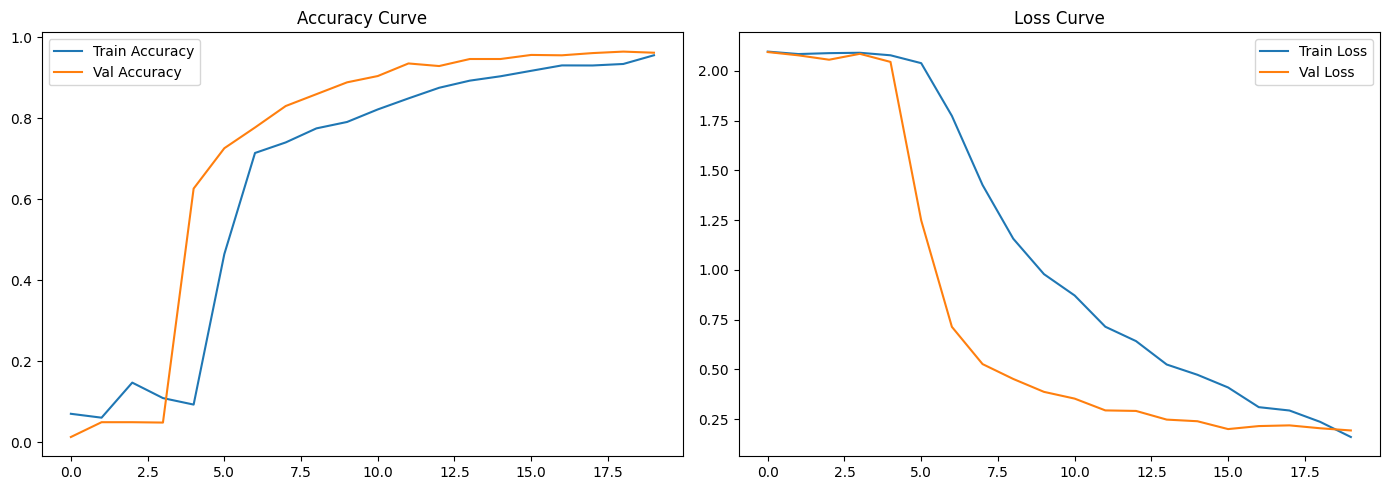

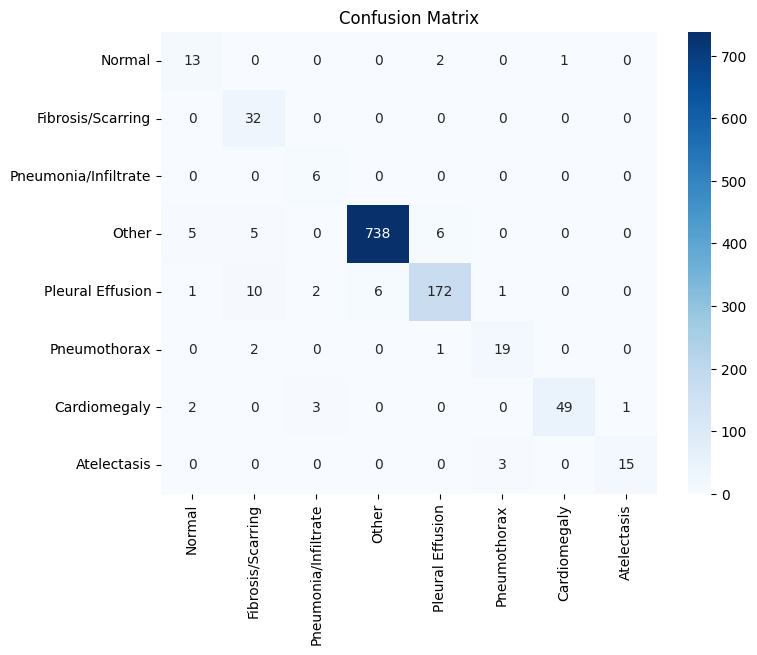

In [ ]:
class_names = df['impression_class'].unique()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy Curve')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)

# -----------------------------------------------
# Confusion Matrix
# -----------------------------------------------
y_pred = model.predict([
    X_test_image, 
    X_test_imp, X_test_find, X_test_mesh, X_test_ind, X_test_prob
])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_image, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150)

print(classification_report(
    y_true_classes, y_pred_classes,
    target_names=class_names
))

In [ ]:
def build_hybrid_fusion_model(num_classes=8, vocab_size=MAX_WORDS):
    # ── Inputs ──────────────────────────────────────────
    image_input = keras.Input(shape=(224, 224, 1), name='image_input')
    imp_input   = keras.Input(shape=(SEQ_LENS['impression'],), name='impression_input')
    find_input  = keras.Input(shape=(SEQ_LENS['findings'],),   name='findings_input')
    mesh_input  = keras.Input(shape=(SEQ_LENS['mesh'],),       name='mesh_input')
    ind_input   = keras.Input(shape=(SEQ_LENS['indication'],), name='indication_input')
    prob_input  = keras.Input(shape=(SEQ_LENS['problems'],),   name='problems_input')

    # ── Image Features ──────────────────────────────────
    img_model, _ = build_efficientnet_model(feature_dim=256, num_classes=num_classes)
    img_features = img_model(image_input)                          # [batch, 256]

    # ── Clinical Features (BiLSTM) ───────────────────────
    clin_model    = build_clinical_bilstm(vocab_size=vocab_size)
    clin_features = clin_model([imp_input, find_input,
                                mesh_input, ind_input, prob_input]) # [batch, 128]

    img_proj  = layers.Dense(128, activation='relu', name='img_proj')(img_features)
    clin_proj = layers.Dense(128, activation='relu', name='clin_proj')(clin_features)

    combined = layers.Concatenate()([img_proj, clin_proj])  # [batch, 256]
    attn = layers.Dense(64,  activation='tanh')(combined)
    attn = layers.Dense(2,   activation='softmax', name='attention_weights')(attn)

    img_weighted  = layers.Multiply()([img_proj,  attn[:, 0:1]])
    clin_weighted = layers.Multiply()([clin_proj, attn[:, 1:2]])

    fused = layers.Add(name='hybrid_fusion')([img_weighted, clin_weighted])

    x = layers.Dense(128, activation='relu')(fused)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(
        inputs=[image_input, imp_input, find_input, mesh_input, ind_input, prob_input],
        outputs=outputs,
        name='hybrid_fusion_model'
    )
    return model

hybrid_model = build_hybrid_fusion_model(num_classes=8)
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)


In [97]:
history = hybrid_model.fit(
    [X_train_image, X_train_imp, X_train_find, X_train_mesh, X_train_ind, X_train_prob],
    y_train_image,
    validation_data=(
        [X_val_image, X_val_imp, X_val_find, X_val_mesh, X_val_ind, X_val_prob],
        y_val_image
    ),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict
)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.2225 - loss: 2.0858 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0201 - val_loss: 2.0724 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.2540 - loss: 2.0771 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.6746 - val_loss: 2.0305 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.6972 - loss: 1.9795 - precision: 0.9300 - recall: 0.1770 - val_accuracy: 0.7395 - val_loss: 0.9307 - val_precision: 0.9380 - val_recall: 0.5119
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.7084 - loss: 1.7589 - precision: 0.9184 - recall: 0.5646 - val_accuracy: 0.7139 - val_loss: 0.7672 - val_precision: 0.9293 - val_recall: 0.6490
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.7015 - loss: 1.6086 - precision: 0.8966 - recall: 0.5825 - val_accu

In [98]:
model.save('fusion_model.h5')

In [99]:
hybrid_model.save('hybrid_fusion_model.h5')

35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 979ms/step
                      precision    recall  f1-score   support

              Normal       0.79      0.69      0.73        16
   Fibrosis/Scarring       0.89      0.97      0.93        32
Pneumonia/Infiltrate       0.50      0.67      0.57         6
               Other       1.00      0.97      0.98       754
    Pleural Effusion       0.88      0.90      0.89       192
        Pneumothorax       0.66      0.95      0.78        22
        Cardiomegaly       0.96      0.80      0.87        55
         Atelectasis       0.59      0.89      0.71        18

            accuracy                           0.94      1095
           macro avg       0.78      0.85      0.81      1095
        weighted avg       0.95      0.94      0.95      1095



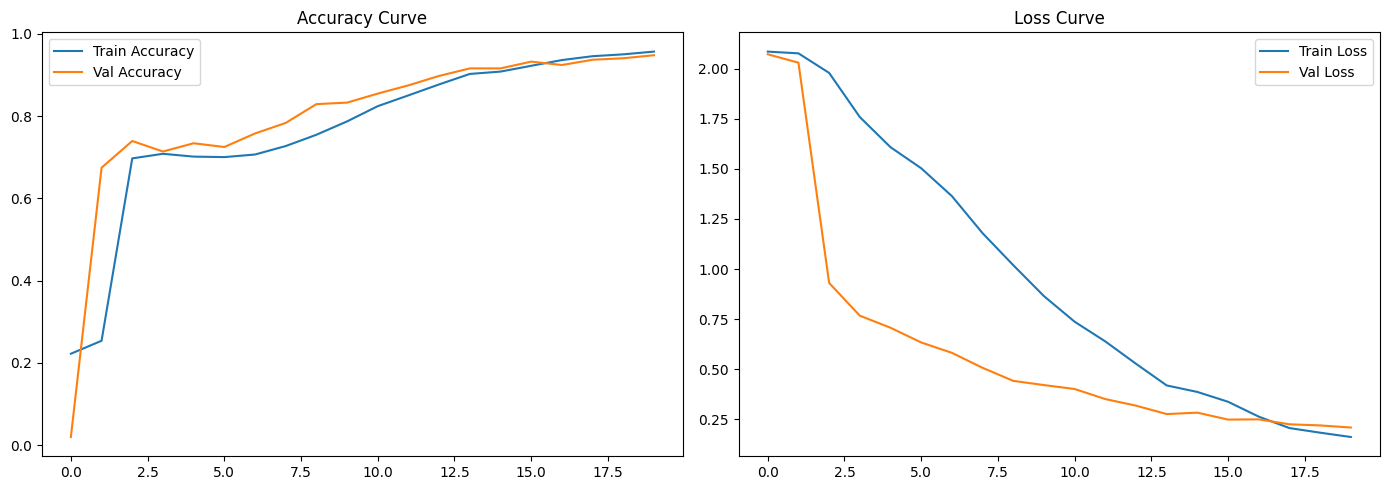

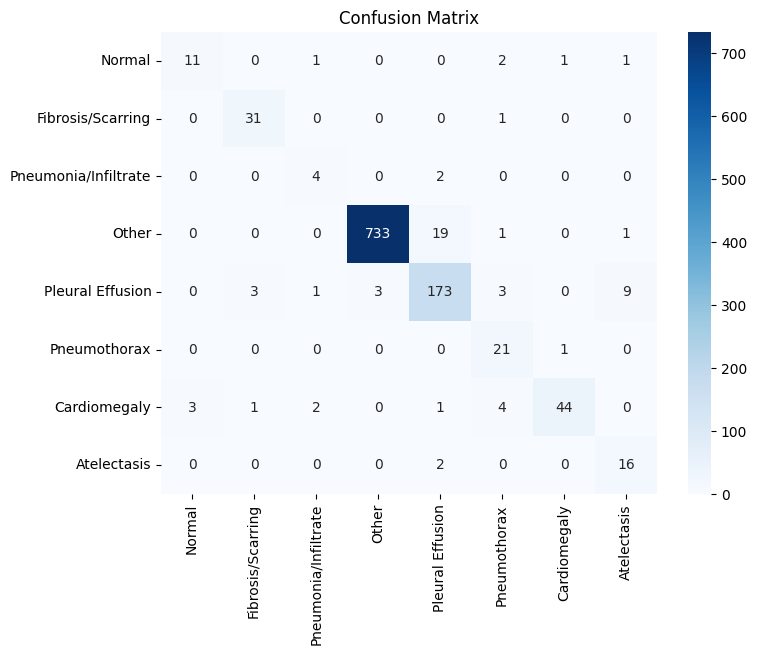

In [ ]:
class_names = df['impression_class'].unique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy Curve')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)


y_pred = hybrid_model.predict([
    X_test_image, 
    X_test_imp, X_test_find, X_test_mesh, X_test_ind, X_test_prob
])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_image, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150)

print(classification_report(
    y_true_classes, y_pred_classes,
    target_names=class_names
))

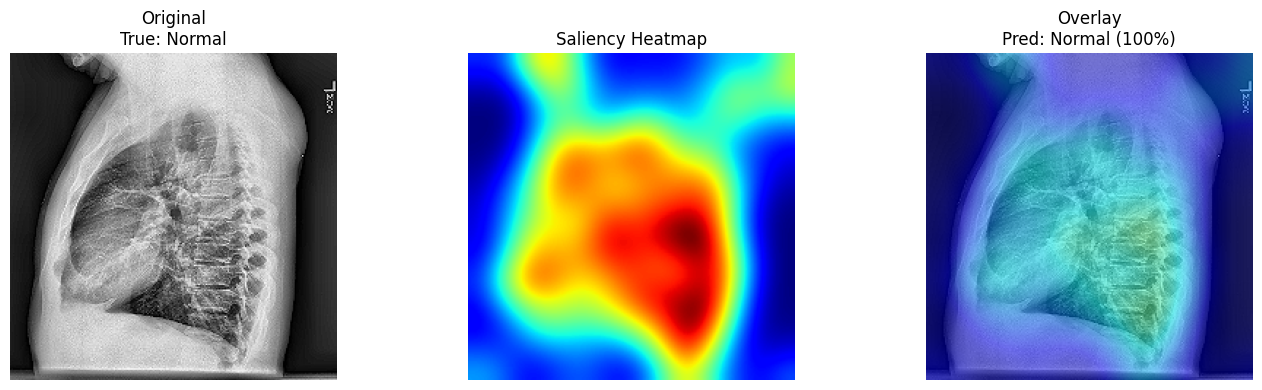

In [ ]:
def get_gradcam_heatmap(model, image, text_inputs, class_idx, smooth=True):

    image_tensor = tf.Variable(tf.cast(image, tf.float32))
    text_tensors = [tf.cast(t, tf.float32) for t in text_inputs]
    all_inputs   = [image_tensor] + text_tensors

    with tf.GradientTape() as tape:
        predictions = model(all_inputs, training=False)
        class_score = predictions[:, class_idx]

    grads = tape.gradient(class_score, image_tensor)

    if grads is None:
        print("❌ grads is None!")
        return None

    heatmap = tf.abs(grads[0, :, :, 0]).numpy()

    from scipy.ndimage import gaussian_filter
    heatmap = gaussian_filter(heatmap, sigma=15)

    # ✅ normalize
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap


def show_gradcam(model, image_array, text_inputs, true_label, class_names):

    image_batch  = np.expand_dims(image_array, axis=0)
    text_tensors = [tf.cast(t, tf.float32) for t in text_inputs]
    all_inputs   = [tf.cast(image_batch, tf.float32)] + text_tensors

    preds      = model.predict(all_inputs, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class]

    heatmap = get_gradcam_heatmap(model, image_batch, text_inputs, pred_class)
    if heatmap is None:
        return

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    original_rgb = np.concatenate([image_array * 255] * 3, axis=-1).astype(np.uint8)

    overlayed = cv2.addWeighted(original_rgb, 0.5, heatmap_colored, 0.5, 0)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(image_array[:, :, 0], cmap='gray')
    axes[0].set_title(f'Original\nTrue: {class_names[true_label]}')
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Saliency Heatmap')
    axes[1].axis('off')

    axes[2].imshow(overlayed)
    axes[2].set_title(f'Overlay\nPred: {class_names[pred_class]} ({confidence:.0%})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_result.png', dpi=150, bbox_inches='tight')
    plt.show()

sample_idx   = 106
sample_image = X_test_image[sample_idx]
sample_texts = [
    X_test_imp[sample_idx:sample_idx+1],
    X_test_find[sample_idx:sample_idx+1],
    X_test_mesh[sample_idx:sample_idx+1],
    X_test_ind[sample_idx:sample_idx+1],
    X_test_prob[sample_idx:sample_idx+1],
]
true_label = np.argmax(y_test_image[sample_idx])

show_gradcam(hybrid_model, sample_image, sample_texts, true_label, le.classes_)

In [115]:
image_model     = hybrid_model.get_layer('image_model')
efficientnet_b3 = image_model.get_layer('efficientnetb3')

print("=== efficientnetb3 inputs ===")
print(efficientnet_b3.inputs)

print("\n=== efficientnetb3 output ===")
print(efficientnet_b3.output)

print("\n=== hybrid_model inputs ===")
for inp in hybrid_model.inputs:
    print(inp.name, inp.shape)

print("\n=== image_model inputs ===")
print(image_model.inputs)

print("\n=== image_model output ===")
print(image_model.output)

=== efficientnetb3 inputs ===
[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2458>]

=== efficientnetb3 output ===
<KerasTensor shape=(None, 7, 7, 1536), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2842>

=== hybrid_model inputs ===
image_input (None, 224, 224, 1)
impression_input (None, 100)
findings_input (None, 150)
mesh_input (None, 50)
indication_input (None, 80)
problems_input (None, 50)

=== image_model inputs ===
[<KerasTensor shape=(None, 224, 224, 1), dtype=float32, sparse=False, ragged=False, name=image_input>]

=== image_model output ===
<KerasTensor shape=(None, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2847>
